In [ ]:
# **Assignment 1 : Tensorflow and Keras - Load Dataset, Split Dataset, Scale Down / Normalization, Evaluate model**

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


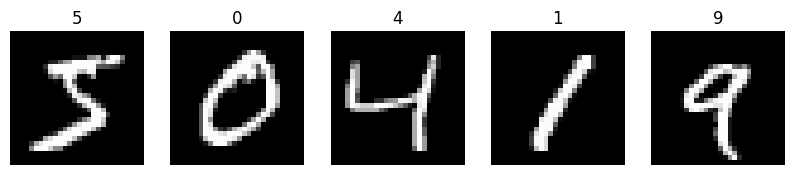

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Maximum Pixel Value:", x_train.max())
print("Minimum Pixel Value:", x_train.min())

Maximum Pixel Value: 1.0
Minimum Pixel Value: 0.0


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9158 - loss: 0.2846 - val_accuracy: 0.9565 - val_loss: 0.1472
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9641 - loss: 0.1168 - val_accuracy: 0.9647 - val_loss: 0.1155
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9752 - loss: 0.0794 - val_accuracy: 0.9693 - val_loss: 0.1030
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9818 - loss: 0.0603 - val_accuracy: 0.9703 - val_loss: 0.1042
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9853 - loss: 0.0467 - val_accuracy: 0.9752 - val_loss: 0.0906


In [8]:
predictions = model.predict(x_test)

import numpy as np

print("Predicted Label:", np.argmax(predictions[0]))
print("Actual Label:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Label: 7
Actual Label: 7


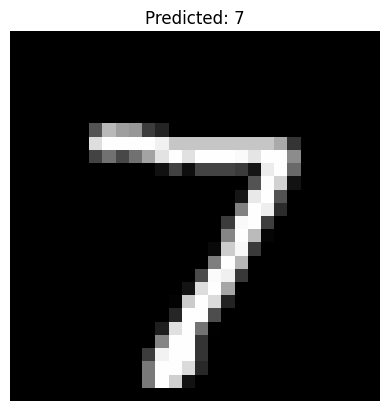

In [9]:
plt.imshow(x_test[0], cmap='gray')
plt.title("Predicted: {}".format(np.argmax(predictions[0])))
plt.axis('off')
plt.show()